In [49]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
%matplotlib inline

In [50]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [51]:
df = pd.read_csv(data)

In [52]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [53]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

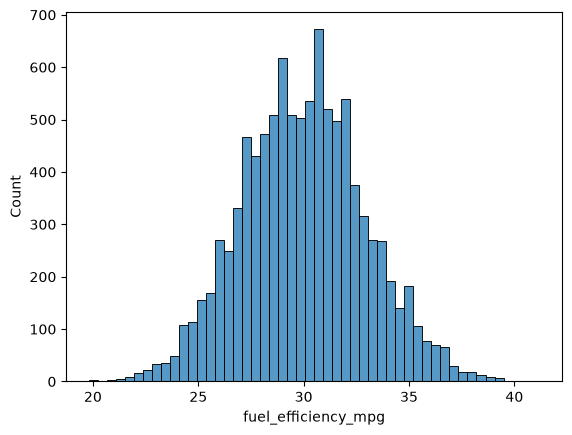

In [54]:
sns.histplot(df['fuel_efficiency_mpg'], bins= 50)

### Look at the fuel_efficiency_mpg variable. Does it have a long tail?

- No it does not have a left tail. It is not skewed (Instead, it is normally distributed)

## Question 1
### There's one column with missing values. What is it?

In [55]:
len(df)

10000

In [56]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Column with missing value: horsepower

### Question 2: Median horsepower

In [57]:
print(df['horsepower'].median())

254.0


### Split dataset

In [58]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [59]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [60]:
X_train = df_train[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].values

In [61]:
y_train = df_train['fuel_efficiency_mpg'].values

In [62]:
X_val = df_val[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].values

y_val = df_val['fuel_efficiency_mpg'].values

### Fill with zero steps

In [63]:
X_train = df_train[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(0).values

In [64]:
X_val = df_val[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(0).values

In [65]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

In [66]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [67]:
w0, w = train_linear_regression(X_train, y_train)

In [68]:
y_pred = w0 + X_val.dot(w)

In [69]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [70]:
score = rmse(y_val, y_pred)
print(round(score, 3))

2.205


### Fill with training mean

In [71]:
mean = df_train['engine_displacement'].mean()
mean

np.float64(2268.2033333333334)

In [72]:
X_train = df_train[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(mean).values

In [73]:
X_val = df_val[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(mean).values

In [74]:
df_train['engine_displacement'].mean()

np.float64(2268.2033333333334)

In [75]:
w0, w = train_linear_regression(X_train, y_train)

In [76]:
y_pred = w0 + X_val.dot(w)

In [77]:
score = rmse(y_val, y_pred)
print(round(score, 3))

2.206


In [78]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [79]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:

    X_train = df_train[
        [
            'engine_displacement',
            'horsepower',
            'vehicle_weight',
            'model_year'
        ]
    ].fillna(0).values

    X_val = df_val[
        [
            'engine_displacement',
            'horsepower',
            'vehicle_weight',
            'model_year'
        ]
    ].fillna(0).values

    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    print(r, round(score, 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [80]:
scores = []

for seed in range(10):
    np.random.seed(seed)

    n = len(df)

    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

In [82]:
X_train = df_train[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(0).values

In [83]:
X_val = df_val[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]
].fillna(0).values

In [84]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

In [85]:
w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)

scores.append(score)

In [90]:
print(round(np.std(scores), 3))

0.029


In [91]:
np.random.seed(9)

n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [92]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [93]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

In [94]:
y_full_train = np.concatenate([y_train, y_val])

In [95]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

X_full_train = df_full_train[features].fillna(0).values
X_test = df_test[features].fillna(0).values

In [96]:
w0, w = train_linear_regression_reg(
    X_full_train,
    y_full_train,
    r=0.001
)

In [97]:
y_pred = w0 + X_test.dot(w)

In [98]:
score = rmse(y_test, y_pred)

print(round(score, 3))

2.236
